In [69]:
# Importing the important and required modules.
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

The solution of task-1.

In [ ]:
data = pd.read_csv('car_prediction_data.csv')
print("Displaying the first 5 rows of the given dataset:")
print(data.head())  # Displaying the first 5 rows
print("Displaying the last 5 rows of the given dataset:")
print(data.tail())  # Displaying the last 5 rows.\

print("The shape of this dataset is : " , data.shape)
print("The name of the columns are as follows:")
print(data.columns)
print("The datatypes of each ccolumns are :")
print(data.dtypes)

Displaying the first 5 rows of the given dataset:
  Car_Name  Year  Selling_Price  ...  Seller_Type  Transmission Owner
0     ritz  2014           3.35  ...       Dealer        Manual     0
1      sx4  2013           4.75  ...       Dealer        Manual     0
2     ciaz  2017           7.25  ...       Dealer        Manual     0
3  wagon r  2011           2.85  ...       Dealer        Manual     0
4    swift  2014           4.60  ...       Dealer        Manual     0

[5 rows x 9 columns]
Displaying the last 5 rows of the given dataset:
    Car_Name  Year  Selling_Price  ...  Seller_Type  Transmission Owner
296     city  2016           9.50  ...       Dealer        Manual     0
297     brio  2015           4.00  ...       Dealer        Manual     0
298     city  2009           3.35  ...       Dealer        Manual     0
299     city  2017          11.50  ...       Dealer        Manual     0
300     brio  2016           5.30  ...       Dealer        Manual     0

[5 rows x 9 columns]
The s

Solution of task-2.

In [ ]:
print("The information of this dataset is:")
print(data.info())

print("Satistical information of this set is as follows:")
print(data.describe())

print("The number of missing values are:")
print(data.isnull().sum())

print("The number of duplicated rows are: " , data.duplicated().sum())
duplicated_rows = data[data.duplicated()]  # Stores the duplicated rows.
print("The duplicated rows are :")
print(duplicated_rows)

data = data.drop_duplicates()
data

The information of this dataset is:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
Satistical information of this set is as follows:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


Beginning solution of task-3.

In [ ]:
data['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [22]:
data['Seller_Type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [23]:
data['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

Here the fuel type , seller type and transmission are cotegorical columns.

In [61]:
label_encoder = LabelEncoder()
data['Fuel_Type'] = label_encoder.fit_transform(data['Fuel_Type'])
data['Seller_Type'] = label_encoder.fit_transform(data['Seller_Type'])
data['Transmission'] = label_encoder.fit_transform(data['Transmission'])

# Here in fuel type column : 1 = Diesel , 2 = Petrol , 0 = CNG
# Here in seller type column : 0 = Dealer and 1 = Individual
# Here in transmission column : 1 = Manual and 0 = Automatic

data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,0,1,0
297,brio,2015,4.00,5.90,60000,2,0,1,0
298,city,2009,3.35,11.00,87934,2,0,1,0
299,city,2017,11.50,12.50,9000,1,0,1,0


In [35]:
invalid_prices = data[data['Selling_Price'] > data['Present_Price']]
print("Number of rows with invalid prices are : ",len(invalid_prices))

negative_kms = data[data['Kms_Driven'] < 0]
negative_prices = data[data['Selling_Price'] < 0]
print(f"The number of rows with negative kms are : {len(negative_kms)} and negative prices are : {len(negative_prices)}")

future_date = data[data['Year'] > 2026]
print("The number of rows with future dates are : ",len(future_date))

Number of rows with invalid prices are :  0
The number of rows with negative kms are : 0 and negative prices are : 0
The number of rows with future dates are :  0


As Seen from the above that we don't have the invalid and inconsistent data.

Beginning of task-4.

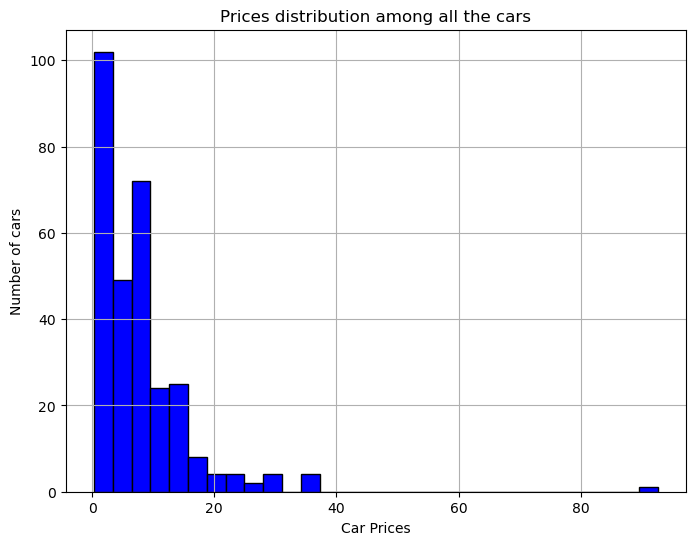

In [42]:
plt.figure(figsize=(8,6))
plt.hist(data['Present_Price'] , bins=30, color='blue' , edgecolor='black')
plt.xlabel("Car Prices")
plt.ylabel('Number of cars')
plt.title("Prices distribution among all the cars")
plt.grid()
plt.savefig("Price_Distribution.png" , dpi=300 , bbox_inches='tight')
plt.show()

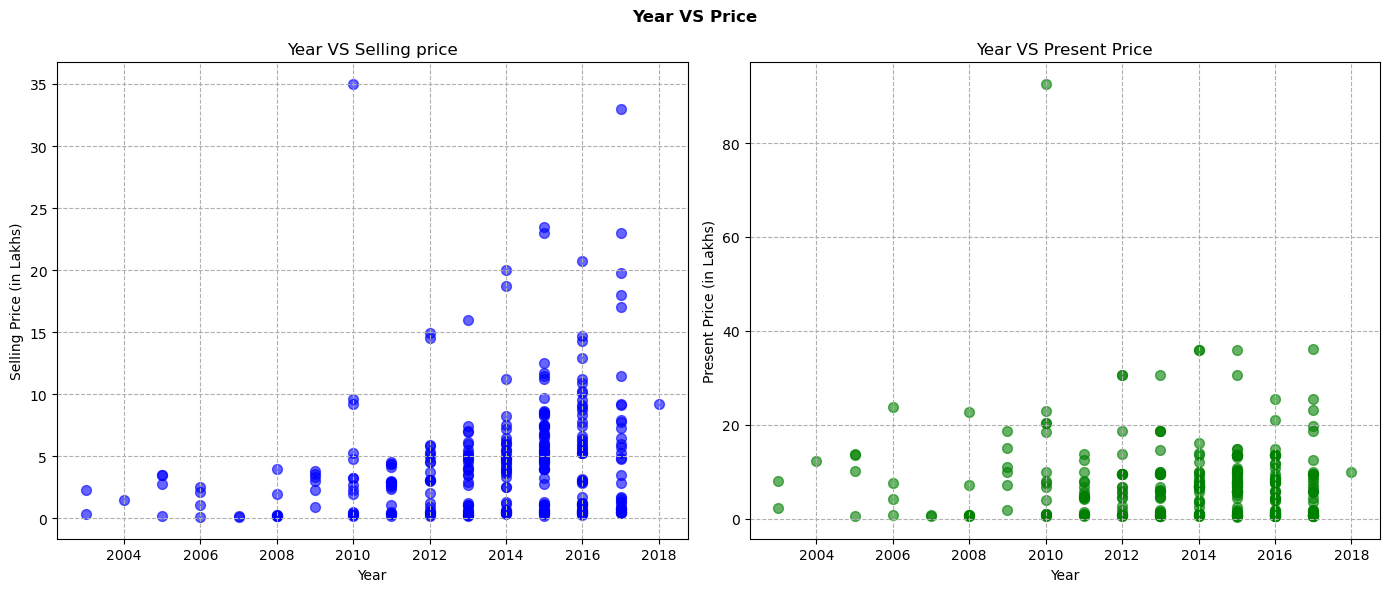

In [46]:
fig, axes = plt.subplots(1,2 , figsize=(14,6) , sharex=True)

axes[0].scatter(data['Year'] , data['Selling_Price'] , color='blue' , alpha=0.6 , s=50)
axes[0].set_title('Year VS Selling price')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Selling Price (in Lakhs)')
axes[0].grid(True , linestyle='--')

axes[1].scatter(data['Year'] , data['Present_Price'] , color='green' , alpha=0.6 , s=50)
axes[1].set_title('Year VS Present Price')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Present Price (in Lakhs)')
axes[1].grid(True , linestyle='--')

plt.suptitle('Year VS Price' , fontweight='bold')
plt.tight_layout()
plt.savefig('Year_VS_Price.png',dpi=300 , bbox_inches='tight')
plt.show()

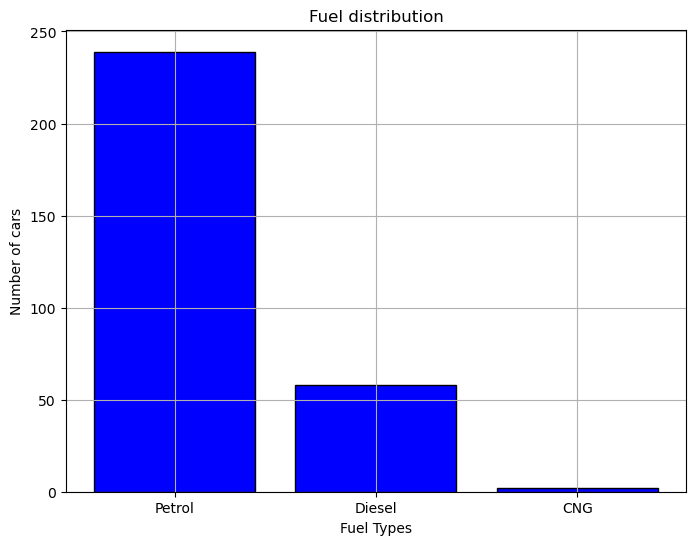

In [66]:
fuel_counts = data['Fuel_Type'].value_counts().sort_values(ascending=False)

mapping = {0: 'CNG', 1: 'Diesel', 2: 'Petrol'}
names = [mapping[i] for i in fuel_counts.index]

plt.figure(figsize=(8,6))
plt.bar(names,fuel_counts.values, color='blue' , edgecolor='black')
plt.xlabel("Fuel Types")
plt.ylabel('Number of cars')
plt.title("Fuel distribution")
plt.grid()
plt.savefig("Fuel_Distribution.png" , dpi=300 , bbox_inches='tight')
plt.show()

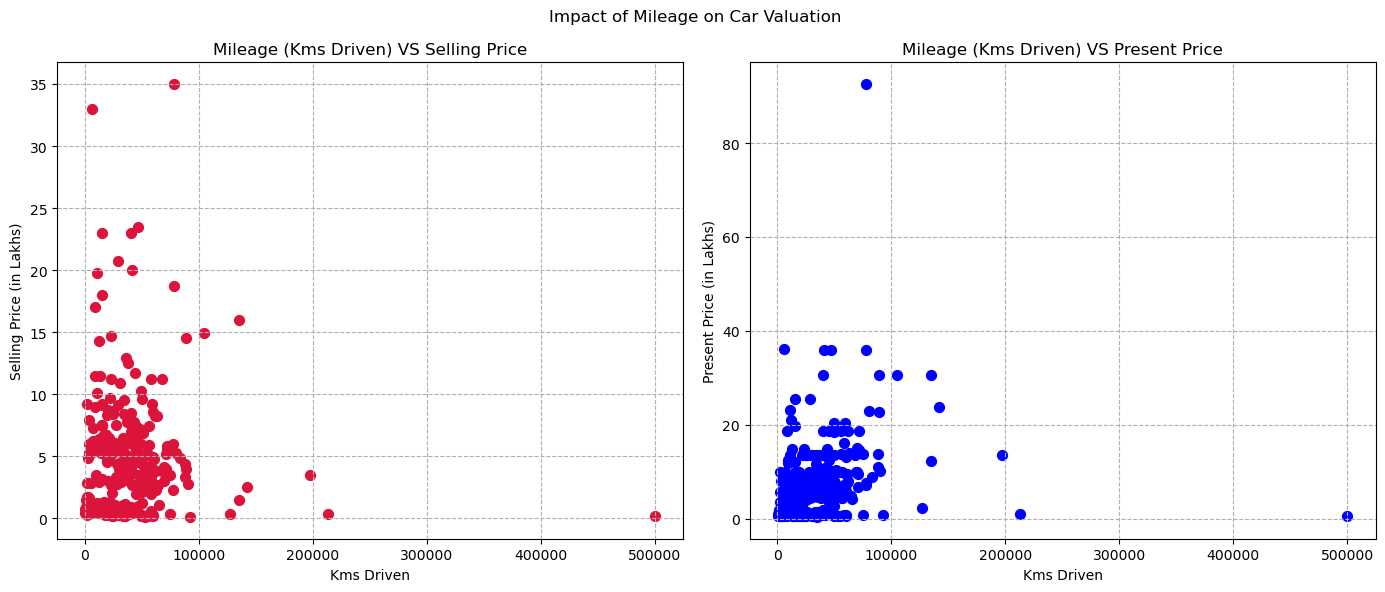

In [67]:
fig, axes = plt.subplots(1,2 , figsize=(14,6))

axes[0].scatter(data['Kms_Driven'] , data['Selling_Price'] , color='crimson' , s=50)
axes[0].set_xlabel('Kms Driven')
axes[0].set_ylabel('Selling Price (in Lakhs)')
axes[0].set_title("Mileage (Kms Driven) VS Selling Price")
axes[0].grid(True , linestyle='--')

axes[1].scatter(data['Kms_Driven'] , data['Present_Price'] , color='blue' , s=50)
axes[1].set_xlabel('Kms Driven')
axes[1].set_ylabel("Present Price (in Lakhs)")
axes[1].set_title('Mileage (Kms Driven) VS Present Price')
axes[1].grid(True , linestyle='--')

plt.suptitle('Impact of Mileage on Car Valuation')
plt.tight_layout()
plt.savefig('mileage_vs_price_scatter.png', dpi=300 , bbox_inches='tight')
plt.show()

Beginning of Task-5

In [68]:
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,0,1,0
297,brio,2015,4.00,5.90,60000,2,0,1,0
298,city,2009,3.35,11.00,87934,2,0,1,0
299,city,2017,11.50,12.50,9000,1,0,1,0


In [83]:
X = data[['Year' , 'Present_Price' , 'Kms_Driven' , 'Fuel_Type' , 'Transmission' , 'Owner']]
y = data['Selling_Price']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.fit_transform(X_test)

Beginning of Task-6

In [77]:
model = LinearRegression()
model.fit(X_train_scaled , y_train)

predictions = model.predict(X_test_scaled)

Beginning of Task-7

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
mae = mean_absolute_error(y_test , predictions)
mse = mean_squared_error(y_test , predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test , predictions)

print("MAE : ", mae)
print("MSE : ", mse)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  1.57448543249509
MSE :  6.752076726771128
RMSE :  2.5984758468708398
R2 :  0.7380200973957672


Beginning of Task-8

In [79]:
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,0,1,0
297,brio,2015,4.00,5.90,60000,2,0,1,0
298,city,2009,3.35,11.00,87934,2,0,1,0
299,city,2017,11.50,12.50,9000,1,0,1,0


In [86]:
sample_data = {
    'Year' : [2015],
    'Present_Price' : [5.90],
    'Kms_Driven' : [60000],
    'Fuel_Type' : [2],
    'Transmission' : [1],
    'Owner' : [0]
}
sampledf = pd.DataFrame(sample_data)
sampledf_scaled = scalar.fit_transform(sampledf)
new_predictions = model.predict(sampledf_scaled)
print(f"The predicted Price of the chosen car is : {new_predictions[0]} Lakh Rupees")

The predicted Price of the chosen car is : 4.58368200836824 Lakh Rupees
